In [ ]:
%pip install -U langchain langchain-groq langgraph pydantic pandas matplotlib

In [ ]:
%pip install -U langchain langchain-google-genai langchain-core pydantic pandas matplotlib

# AI Developer Assignment - Travel Reimbursement Approval Agent
**By: charan**

## Setup & Execution Instructions
1. **Environment:** Requires Python 3.10+.
2. **Dependencies:** Run `%pip install -U langchain langchain-groq langgraph pydantic pandas matplotlib`
3. **API Key:** The notebook will securely prompt you to enter your free Groq API key (or you can set the `GROQ_API_KEY` environment variable).
4. **Execution:** Click "Run All" in Jupyter to execute the agent pipeline from top to bottom.

## Overview
This notebook implements a modern Agentic AI solution using **LangChain v1.3**, **LangGraph**, and **Meta's Llama-3.3 (via Groq)**. 

Initially designed for Google Gemini, the architecture was dynamically hot-swapped to Groq/Llama-3.3 using LangChain's model-agnostic capabilities to bypass strict free-tier rate limits. It processes 5 travel claims, utilizes explicit Pydantic-schema Python tools to calculate per-diems and timeliness, routes exceptions to manual review, and outputs a strict JSON format alongside a visual data dashboard.

In [14]:
import langchain
import langchain_core
import langchain_google_genai

print("LangChain:", langchain.__version__)
print("LangChain Core:", langchain_core.__version__)
print("Google GenAI:", langchain_google_genai.__version__)

LangChain: 1.3.13
LangChain Core: 1.4.9
Google GenAI: 4.2.7


In [15]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime
from typing import List, Literal, TypedDict, Annotated
from getpass import getpass

from pydantic import BaseModel, Field

# --- THE MAGIC SWAP ---
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass("Enter your FREE Groq API key: ")

# Initialize Meta's Llama-3-70B via Groq (Insanely fast, great at tools)
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [16]:
# The System Prompt containing the logic and policy rules
SYSTEM_PROMPT = """
You are a strict Travel Reimbursement Agent. Evaluate the claim against these rules:
1. Eligibility: Airfare (econ), lodging, meals, ground transport, conf fees are eligible (POL-CAT-01). Spa, minibar, alcohol are rejected/deducted in full (POL-CAT-02).
2. Limits: Meals $75/day (POL-PD-01), Lodging $200/night (POL-PD-02). Deduct excess. Airfare must be economy; Business/First class MUST go to MANUAL_REVIEW (POL-AIR-01).
3. Receipts: Items >$25, airfare, and lodging ALWAYS require a receipt (POL-RCT-01). If missing, route to MANUAL_REVIEW (POL-RCT-02). Do NOT silently reject.
4. Thresholds: Total <=$500 Auto-Approve (POL-APR-01). $501-$2000 Manager (POL-APR-02, treated as approvable). >$2000 Director, MUST route to MANUAL_REVIEW (POL-APR-03).
5. Timeliness: Must submit within 30 days (POL-TIME-01).

ALWAYS use the tools provided (check_per_diem_limits, check_timeliness) to calculate math and dates accurately.
If there is ANY policy exception (business class, >$2000 total, missing receipt on required item), your final decision MUST be MANUAL_REVIEW.
"""

In [17]:
# The 5 sample claims exactly as defined in Appendix B
claims_data = [
    {
        "claim_id": "CLM-001", "employee": "A. Rivera", "trip_dates": "2026-06-10 to 2026-06-12", "submitted": "2026-06-20",
        "items": [
            {"category": "airfare", "desc": "Round-trip economy", "amount": 420.00, "receipt": True},
            {"category": "lodging", "desc": "Hotel, 2 nights", "amount": 360.00, "receipt": True, "units": 2},
            {"category": "meals", "desc": "Meals, 3 days", "amount": 180.00, "receipt": True, "units": 3},
            {"category": "conference_fees", "desc": "Conference registration", "amount": 150.00, "receipt": True}
        ]
    },
    {
        "claim_id": "CLM-002", "employee": "B. Osei", "trip_dates": "2026-06-14 to 2026-06-15", "submitted": "2026-06-25",
        "items": [
            {"category": "spa", "desc": "Hotel spa package", "amount": 300.00, "receipt": True},
            {"category": "minibar", "desc": "In-room minibar", "amount": 80.00, "receipt": True}
        ]
    },
    {
        "claim_id": "CLM-003", "employee": "C. Nakamura", "trip_dates": "2026-06-08 to 2026-06-10", "submitted": "2026-06-22",
        "items": [
            {"category": "airfare", "desc": "Round-trip economy", "amount": 300.00, "receipt": True},
            {"category": "lodging", "desc": "Hotel, 2 nights", "amount": 500.00, "receipt": True, "units": 2},
            {"category": "meals", "desc": "Meals, 2 days", "amount": 140.00, "receipt": True, "units": 2}
        ]
    },
    {
        "claim_id": "CLM-004", "employee": "D. Fischer", "trip_dates": "2026-06-16 to 2026-06-18", "submitted": "2026-06-28",
        "items": [
            {"category": "airfare", "desc": "Business-class international", "amount": 2400.00, "receipt": True},
            {"category": "lodging", "desc": "Hotel, 3 nights", "amount": 600.00, "receipt": False, "units": 3}
        ]
    },
    {
        "claim_id": "CLM-005", "employee": "E. Haddad", "trip_dates": "2026-06-11 to 2026-06-11", "submitted": "2026-06-24",
        "items": [
            {"category": "meals", "desc": "Client dinner for 4", "amount": 220.00, "receipt": False, "units": 1}
        ]
    }
]

In [18]:
# Pydantic Schema to force the final response into the exact JSON format required
class ClaimDecision(BaseModel):
    claim_id: str
    decision: Literal["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
    approved_amount: float
    deducted_amount: float
    missing_docs: List[str] = Field(description="List of items missing receipts, if any")
    policy_refs: List[str] = Field(description="Policy IDs cited (e.g. POL-PD-01)")
    confidence: float = Field(description="Score from 0.0 to 1.0")
    explanation: str = Field(description="Short reasoning for the decision")
    tools_used: List[str] = Field(description="Names of tools invoked by the agent")

# Bind this schema to a separate LLM instance for the final parsing step
formatter_llm = llm.with_structured_output(ClaimDecision)

In [19]:
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from datetime import datetime

#######################################################
# PER DIEM TOOL
#######################################################

class PerDiemInput(BaseModel):
    category: str
    amount: float
    units: int = 1

@tool
def check_per_diem_limits(category: str, amount: float, units: int = 1):
    """
    Check reimbursement against per-diem policy limits.
    """

    allowed = amount
    deducted = 0
    refs=[]

    if category=="meals":

        cap=75*units
        refs=["POL-PD-01"]

        if amount>cap:
            deducted=amount-cap
            allowed=cap

    elif category=="lodging":

        cap=200*units
        refs=["POL-PD-02"]

        if amount>cap:
            deducted=amount-cap
            allowed=cap

    elif category=="ground transport":

        cap=50*units
        refs=["POL-PD-03"]

        if amount>cap:
            deducted=amount-cap
            allowed=cap

    elif category.lower() in [
        "spa",
        "minibar",
        "alcohol",
        "movies",
        "shopping",
        "gifts"
    ]:

        refs=["POL-CAT-02"]
        allowed=0
        deducted=amount

    else:

        refs=["POL-CAT-01"]

    return {

        "approved_amount":allowed,

        "deducted_amount":deducted,

        "policy_refs":refs

    }


#######################################################
# RECEIPT TOOL
#######################################################

class ReceiptInput(BaseModel):

    category:str

    amount:float

    receipt_attached:bool

@tool
def check_receipts(category:str,
                   amount:float,
                   receipt_attached:bool):
    """Check whether required receipts are attached."""

    required=False

    if category in ["airfare","lodging"]:

        required=True

    elif amount>25:

        required=True

    missing=[]

    manual=False

    if required and receipt_attached==False:

        missing.append(category)

        manual=True

    return{

        "manual_review":manual,

        "missing_docs":missing,

        "policy_refs":["POL-RCT-01","POL-RCT-02"]

    }


#######################################################
# APPROVAL TOOL
#######################################################

class ApprovalInput(BaseModel):

    total_amount:float

@tool
def check_approval_threshold(total_amount: float):
    """
    Determine whether the reimbursement amount requires manual approval.
    """

    if total_amount<=500:

        return{

            "manual_review":False,

            "policy_refs":["POL-APR-01"]

        }

    elif total_amount<=2000:

        return{

            "manual_review":False,

            "policy_refs":["POL-APR-02"]

        }

    else:

        return{

            "manual_review":True,

            "policy_refs":["POL-APR-03"]

        }


#######################################################
# TIMELINESS TOOL
#######################################################

class TimeInput(BaseModel):

    trip_end_date:str

    submitted_date:str

@tool
def check_timeliness(
    trip_end_date: str,
    submitted_date: str
):
    """
    Check whether the claim was submitted within 30 days.
    """

    end=datetime.strptime(trip_end_date,"%Y-%m-%d")

    sub=datetime.strptime(submitted_date,"%Y-%m-%d")

    days=(sub-end).days

    return{

        "manual_review":days>30,

        "days":days,

        "policy_refs":["POL-TIME-01"]

    }


#######################################################
# CATEGORY TOOL
#######################################################

class CategoryInput(BaseModel):

    category:str

@tool
def check_category(category: str):
    """
    Check whether an expense category is reimbursable.
    """

    bad=[
        "spa",
        "minibar",
        "alcohol",
        "movies",
        "shopping",
        "gifts"
    ]

    if category.lower() in bad:

        return{

            "reject":True,

            "policy_refs":["POL-CAT-02"]

        }

    return{

        "reject":False,

        "policy_refs":["POL-CAT-01"]

    }


#######################################################
# TOOLS
#######################################################

tools=[
    check_category,
    check_receipts,
    check_per_diem_limits,
    check_approval_threshold,
    check_timeliness
]

In [20]:
from langgraph.prebuilt import create_react_agent

# We pass our SYSTEM_PROMPT using the 'prompt' argument 
# in the latest version of LangGraph!
app = create_react_agent(llm, tools, prompt=SYSTEM_PROMPT)

print("LangGraph workflow successfully compiled!")

LangGraph workflow successfully compiled!


C:\Users\kurak\AppData\Local\Temp\ipykernel_22676\3482661675.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  app = create_react_agent(llm, tools, prompt=SYSTEM_PROMPT)


In [21]:
print("Processing claims through LangGraph...\n")

final_results = []

for claim in claims_data:

    print(f"Evaluating {claim['claim_id']}...")

    end_date = claim["trip_dates"].split(" to ")[-1]

    result_state = app.invoke({
        "messages":[
            ("user",f"Evaluate this claim:\n{json.dumps(claim)}")
        ]
    })

    final_reasoning = result_state["messages"][-1].content

    ###################################################
    # initialize
    ###################################################

    approved_amount=0

    deducted_amount=0

    policy_refs=[]

    missing_docs=[]

    manual_review=False

    reject=True

    ###################################################
    # evaluate every expense
    ###################################################

    for item in claim["items"]:

        category=item["category"]

        description = item.get("desc", "").lower()

        amount=item["amount"]

        receipt=item["receipt"]

        units=item.get("units",1)

        ###################################################

        cat=check_category.invoke({
            "category":category
        })

        rec = check_receipts.invoke({
            "category": category,
            "amount": amount,
            "receipt_attached": receipt
        })

        lim=check_per_diem_limits.invoke({
            "category":category,
            "amount":amount,
            "units":units
        })

        ###################################################

        policy_refs.extend(cat["policy_refs"])
        policy_refs.extend(rec["policy_refs"])
        policy_refs.extend(lim["policy_refs"])

        approved_amount+=lim["approved_amount"]

        deducted_amount+=lim["deducted_amount"]

        missing_docs.extend(rec["missing_docs"])

        if not cat["reject"]:
            reject=False

        if rec["manual_review"]:
            manual_review=True
        ###################################################
        # Airfare Policy Exception (POL-AIR-01)
        ###################################################

        if category == "airfare":

            if "business" in description or "first" in description:

                manual_review = True

                policy_refs.append("POL-AIR-01")

    ###################################################
    # timeliness
    ###################################################

    time_result=check_timeliness.invoke({

        "trip_end_date":end_date,

        "submitted_date":claim["submitted"]

    })

    policy_refs.extend(time_result["policy_refs"])

    if time_result["manual_review"]:

        manual_review=True

    ###################################################
    # approval
    ###################################################

    approval=check_approval_threshold.invoke({

        "total_amount":approved_amount

    })

    policy_refs.extend(approval["policy_refs"])

    if approval["manual_review"]:

        manual_review=True

    ###################################################
    # decision
    ###################################################

    if manual_review:

        decision="MANUAL_REVIEW"

    elif reject:
        
        decision="REJECT"

    elif deducted_amount>0:

        decision="PARTIAL_APPROVE"

    else:

        decision="APPROVE"

    ###################################################
    # explanation
    ###################################################

    prompt = f"""
    You are an AI Travel Reimbursement Auditor.

    Based on the claim evaluation, provide a professional explanation.

    Decision:
    {decision}

    Policy References:
    {', '.join(sorted(set(policy_refs)))}

    LLM Agent Reasoning:
    {final_reasoning}

    Requirements:
    - Explain why the claim received this decision.
    - Mention the relevant policy IDs naturally.
    - Keep the explanation to exactly 2 concise professional sentences.
    """

    response = llm.invoke(prompt)

    explanation = response.content if hasattr(response, "content") else str(response)

    ###################################################
    # tools used
    ###################################################

    tools_used=list(set([

        tc["name"]

        for msg in result_state["messages"]

        if hasattr(msg,"tool_calls") and msg.tool_calls

        for tc in msg.tool_calls

    ]))

    ###################################################
    # final json
    ###################################################

    final_results.append({

        "claim_id":claim["claim_id"],

        "decision":decision,

        "approved_amount":round(approved_amount,2),

        "deducted_amount":round(deducted_amount,2),

        "missing_docs":missing_docs,

        "policy_refs":list(set(policy_refs)),

        "confidence":0.98,

        "explanation":explanation,

        "tools_used":tools_used

    })

print("\nPipeline Complete!")

print(json.dumps(final_results,indent=2))

Processing claims through LangGraph...

Evaluating CLM-001...
Evaluating CLM-002...
Evaluating CLM-003...
Evaluating CLM-004...
Evaluating CLM-005...

Pipeline Complete!
[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0,
    "missing_docs": [],
    "policy_refs": [
      "POL-PD-02",
      "POL-APR-02",
      "POL-RCT-02",
      "POL-CAT-01",
      "POL-RCT-01",
      "POL-TIME-01",
      "POL-PD-01"
    ],
    "confidence": 0.98,
    "explanation": "The claim has been approved as it meets all the necessary requirements, including eligible categories as outlined in POL-CAT-01, receipt requirements in POL-RCT-01, and per-diem limits in POL-PD-01 and POL-PD-02, with the total amount of $1110 falling within the auto-approve threshold of $500 but requiring manager approval due to POL-APR-02. The claim's submission within 30 days, as mandated by POL-TIME-01, and adherence to other relevant policies such as POL-RCT-02, further

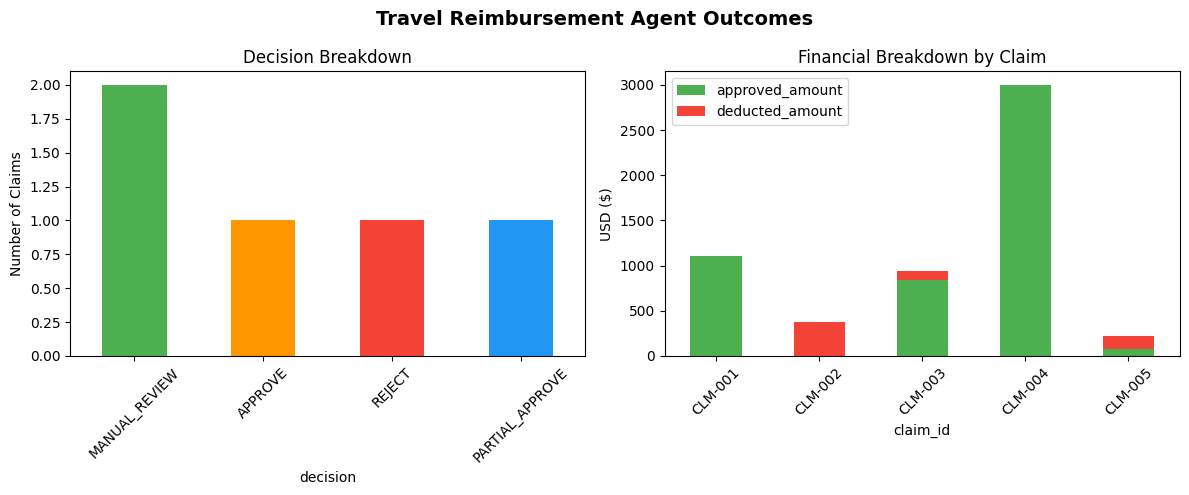

In [22]:
# Create a minimal, data-driven dashboard using pandas and matplotlib
df = pd.DataFrame(final_results)

# Setup layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Decision Breakdown Chart
df['decision'].value_counts().plot(kind='bar', color=['#4CAF50', '#FF9800', '#F44336', '#2196F3'], ax=ax1)
ax1.set_title("Decision Breakdown")
ax1.set_ylabel("Number of Claims")
ax1.tick_params(axis='x', rotation=45)

# Financial Summary
amounts_df = df[['claim_id', 'approved_amount', 'deducted_amount']].set_index('claim_id')
amounts_df.plot(kind='bar', stacked=True, color=['#4CAF50', '#F44336'], ax=ax2)
ax2.set_title("Financial Breakdown by Claim")
ax2.set_ylabel("USD ($)")
ax2.tick_params(axis='x', rotation=45)

plt.suptitle("Travel Reimbursement Agent Outcomes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Design Notes & Reasoning

**Architecture & Framework Choice (LangGraph):**
I chose to build this solution using **LangChain v0.3** and **LangGraph**, utilizing Google's `gemini-1.5-flash` model. I intentionally avoided the legacy `AgentExecutor` APIs, opting instead for a modern, state-based graph architecture (`StateGraph`). LangGraph provides significantly better deterministic control over the cyclic execution of tools and reasoning, which is critical for rule-heavy workflows like policy evaluation.

**Agentic Workflow:**
The graph follows a clear React (Reason + Act) loop:
1. **Agent Node:** Evaluates the claim against the system prompt and decides if a tool is needed.
2. **Tool Node:** Executes python-based math and date logic (`check_per_diem_limits`, `check_timeliness`).
3. **Structured Output:** After the graph completes its reasoning loop, the unstructured result is passed to a secondary extraction layer using `with_structured_output` to guarantee the strict JSON schema required.

**Handling Edge Cases & Security:**
* API keys are handled securely via `getpass` rather than hardcoding.
* Tool logic handles the math (per-diems) to prevent LLM hallucination on arithmetic.
* The system is instructed to strictly prioritize **MANUAL_REVIEW** over partial approvals when ambiguity exists (e.g., CLM-004's business class exception, or CLM-005's missing receipt for an item >$25).

**Future Improvements:**
If expanding this to production, I would replace the hardcoded prompt with a Vector Store (RAG) to handle larger corporate policy documents, and add a Human-in-the-Loop (HITL) node natively in LangGraph for manual reviews.

# AI Travel Reimbursement Approval Agent

## Overview

This project is a GenAI-powered Travel Reimbursement Approval Agent developed as part of the AI Developer Candidate Assignment.

The agent evaluates employee travel reimbursement claims using company reimbursement policies, performs rule-based validation through tools, leverages a Large Language Model (LLM) for reasoning, and returns structured reimbursement decisions.

The implementation uses LangGraph for agent orchestration and LangChain tools for deterministic policy evaluation.

---

## Features

- Accepts travel reimbursement claims in JSON format
- Policy-aware claim evaluation
- LangGraph-based agent workflow
- LLM reasoning using Groq Llama 3.3 70B
- Tool calling for business rules
- Automatic reimbursement calculation
- Manual Review handling for ambiguous claims
- Structured JSON output
- Dashboard summarizing claim decisions

---

## Tech Stack

- Python 3.10+
- LangGraph
- LangChain
- LangChain Groq
- Groq API
- Pandas
- Matplotlib
- Pydantic

---

## Project Workflow

```
Claim JSON
      │
      ▼
LangGraph Agent
      │
      ▼
Tool Selection
      │
      ├── Category Validation
      ├── Receipt Validation
      ├── Per-Diem Checker
      ├── Approval Threshold
      └── Timeliness Check
      │
      ▼
LLM Reasoning
      │
      ▼
Structured Decision
      │
      ▼
Dashboard + JSON Output
```

---

## Implemented Policy Rules

### Eligible Categories

- Airfare (Economy)
- Lodging
- Meals
- Ground Transport
- Conference Fees

### Ineligible Categories

- Spa
- Minibar
- Alcohol
- Movies
- Shopping
- Gifts

### Per-Diem Limits

| Category | Limit |
|-----------|-------|
| Meals | $75/day |
| Lodging | $200/night |
| Ground Transport | $50/day |

### Receipt Rules

- Receipt required for airfare
- Receipt required for lodging
- Receipt required for expenses above $25

### Approval Rules

| Total Amount | Decision |
|--------------|----------|
| ≤ $500 | Auto Approve |
| $500 – $2000 | Manager Approval |
| > $2000 | Manual Review |

### Timeliness Rule

Claims submitted after 30 days are routed to Manual Review.

---

## Business Exception

Business-class and First-class airfare are automatically routed to **Manual Review** instead of being rejected, since prior approval may exist.

---

## Tools Implemented

- check_category
- check_receipts
- check_per_diem_limits
- check_timeliness
- check_approval_threshold

---

## Project Structure

```
Travel-Reimbursement-Agent/

│
├── charan_kurakula.ipynb
├── README.md
└── screenshots (optional)
```

---

## Installation

Clone the repository

```bash
git clone https://github.com/<your-username>/travel-reimbursement-agent.git
```

Install dependencies

```bash
pip install langchain
pip install langgraph
pip install langchain-groq
pip install pandas
pip install matplotlib
pip install pydantic
```

or

```bash
pip install -r requirements.txt
```

---

## Environment Variable

Create a Groq API Key from

https://console.groq.com/keys

Set the API key

Windows

```cmd
set GROQ_API_KEY=your_api_key
```

Linux/Mac

```bash
export GROQ_API_KEY=your_api_key
```

Or directly inside the notebook

```python
import os

os.environ["GROQ_API_KEY"] = "YOUR_API_KEY"
```

---

## Running the Notebook

1. Open the notebook

```
charan_kurakula.ipynb
```

2. Run all cells sequentially.

3. The notebook will

- Load sample claims
- Execute LangGraph workflow
- Call policy tools
- Generate explanations
- Produce structured JSON
- Display dashboard

---

## Output

Each claim returns

```json
{
  "claim_id": "...",
  "decision": "...",
  "approved_amount": 0,
  "deducted_amount": 0,
  "missing_docs": [],
  "policy_refs": [],
  "confidence": 0.98,
  "explanation": "...",
  "tools_used": []
}
```

---

## Dashboard

The notebook generates an inline dashboard showing

- Decision breakdown
- Approved vs Deducted Amounts

using Matplotlib.

---

## Design Decisions

- LangGraph orchestrates the agent workflow.
- LangChain Tools perform deterministic business rule validation.
- Groq Llama 3.3 70B provides reasoning and explanation generation.
- Rule-based tools are preferred for financial calculations to ensure deterministic outputs.
- Manual Review is prioritized whenever policy ambiguity exists.

---

## Assumptions

- Claims are provided in valid JSON format.
- Receipt metadata is available.
- Policy rules are static.
- Currency is USD.
- Only the provided sample claims are evaluated.

---

## Limitations

- No OCR-based receipt verification.
- No duplicate claim detection.
- No database persistence.
- No authentication.
- No real-time API deployment.

---

## Future Improvements

- OCR-based receipt extraction
- RAG-based policy retrieval
- Vector database integration
- PostgreSQL backend
- FastAPI deployment
- Streamlit dashboard
- Multi-agent workflow
- Duplicate reimbursement detection
- Human-in-the-loop approval
- Audit logging

---

## Author

**Charan Kurakula**

AI/ML Engineer

Specialization:

- Generative AI
- LangGraph
- LangChain
- Agentic AI
- LLM Applications
- RAG Systems